# Target a Hohmann transfer and inspect solver iterations

A GMAT `Target` block runs a `DifferentialCorrector`: it varies a set of control
variables until a set of goals is met. GMAT records the iteration history — every
variable, every goal residual, every step — to a per-solver data file.
[`Results.solver_runs`][gmat_run.Results] parses that file into a `pandas`
DataFrame, so you can inspect what the targeter did from Python without opening a
log.

This notebook runs a two-burn Hohmann transfer to a geosynchronous orbit and
reads the solver run back. We:

1. Load the mission and run it headlessly.
2. Confirm the targeter converged with the [`Results.converged`][gmat_run.Results.converged]
   shortcut.
3. Display the iteration table and walk its columns.
4. Plot the goal residuals shrinking toward zero, iteration by iteration.
5. Re-run a deliberately capped copy of the mission and watch it *not* converge —
   without an exception.

**Prerequisites.** A local GMAT install (R2026a is the primary development
target) and `pip install gmat-run[examples]` for matplotlib. `solver_runs` itself
needs no optional extra.

## Locate the script

The mission lives next to this notebook as `hohmann_transfer.script` — a trimmed
copy of GMAT's stock `Ex_HohmannTransfer` sample, with the OpenFrames
visualisation resources removed so it runs headless. It starts in a low
elliptical orbit, propagates to perigee, then opens a `Target` block: a
`DifferentialCorrector` named `DC` varies two impulsive burns — the
transfer-orbit-insertion burn `TOI` and the goal-orbit-insertion burn `GOI` — to
`Achieve` two goals: an orbit radius of 42 165 km at apogee and a near-zero
eccentricity.

`gmat_run.locate_gmat()` reports which GMAT install
[`Mission.load`][gmat_run.Mission.load] will bind to.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

from gmat_run import Mission, locate_gmat

install = locate_gmat()
script_path = Path("hohmann_transfer.script").resolve()

print(f"GMAT version: {install.version}")
print(f"Script:       {script_path.name}")
print(f"Exists:       {script_path.exists()}")

GMAT version: R2026a
Script:       hohmann_transfer.script
Exists:       True


## Run the mission and check convergence

`Mission.load(...).run()` parses the script, executes the mission sequence
headlessly, and returns a `Results` object. The `Target` block ran the
`DifferentialCorrector` as part of that sequence — nothing extra is needed to
capture it.

[`Results.converged`][gmat_run.Results.converged] is a `{solver: bool}` shortcut:
the quick yes/no for "did the targeter reach its goals?". For a
`DifferentialCorrector` this verdict is *derived* — GMAT's targeter log ends the
same way whether or not the goals were met, so `gmat-run` checks the final
iteration's residuals against their tolerances. (A `Yukon` optimizer stamps its
own converged marker; the `DifferentialCorrector` does not.)

In [2]:
mission = Mission.load(script_path)
result = mission.run()

print(f"Solver runs: {list(result.solver_runs)}")
print(f"Converged:   {result.converged}")

Solver runs: ['DC']
Converged:   {'DC': True}


## The iteration table

`result.solver_runs["DC"]` is a DataFrame with one row per targeter iteration.
Its columns come straight from the script:

- `iteration` — the iteration number as GMAT counts it.
- One column per `Vary` variable, named verbatim: `TOI.Element1` and
  `GOI.Element1`, the velocity-direction components of the two burns.
- A quartet per `Achieve` goal — `<goal>` (the achieved value),
  `<goal>_desired`, `<goal>_residual` (`achieved − desired`), and
  `<goal>_tolerance`. Here the goals are `DefaultSC.Earth.RMAG` (the orbit
  radius) and `DefaultSC.ECC` (the eccentricity).
- `status` — `"running"` on every row but the last, which carries the terminal
  verdict.

The residual is signed: `DefaultSC.Earth.RMAG_residual` runs negative while the
orbit is still too small, then flips positive at iteration 10, where the targeter
overshoots 42 165 km before settling back onto the goal. Run-level numbers live
on `df.attrs`. Reading the DataFrame is the whole API — no raw `gmat.*` calls.

In [3]:
runs = result.solver_runs["DC"]

print(f"Solver type: {runs.attrs['solver_type']}")
print(f"Mode:        {runs.attrs['solver_mode']}")
print(f"Iterations:  {runs.attrs['n_iterations']}")
print(f"Variables:   {runs.attrs['n_variables']}, goals: {runs.attrs['n_goals']}")

runs

Solver type: DifferentialCorrector
Mode:        Solve
Iterations:  12
Variables:   2, goals: 2


,iteration,TOI.Element1,GOI.Element1,DefaultSC.Earth.RMAG,DefaultSC.Earth.RMAG_desired,DefaultSC.Earth.RMAG_residual,DefaultSC.Earth.RMAG_tolerance,DefaultSC.ECC,DefaultSC.ECC_desired,DefaultSC.ECC_residual,DefaultSC.ECC_tolerance,status
0,1,0.500000,0.500000,9746.509926,42165.0,-32418.490074,0.1,1.365367e-02,0.0,1.365367e-02,0.1,running
1,2,0.700000,0.672730,10994.202696,42165.0,-31170.797304,0.1,1.122083e-02,0.0,1.122083e-02,0.1,running
2,3,0.900000,0.833204,12480.596196,42165.0,-29684.403804,0.1,8.538737e-03,0.0,8.538737e-03,0.1,running
3,4,1.100000,0.980615,14279.787890,42165.0,-27885.212110,0.1,5.543464e-03,0.0,5.543464e-03,0.1,running
4,5,1.300000,1.113768,16500.162453,42165.0,-25664.837547,0.1,2.158880e-03,0.0,2.158880e-03,0.1,running
5,6,1.500000,1.230903,19306.813720,42165.0,-22858.186280,0.1,1.695484e-03,0.0,1.695484e-03,0.1,running
6,7,1.700000,1.329375,22964.209692,42165.0,-19200.790308,0.1,6.064985e-03,0.0,6.064985e-03,0.1,running
7,8,1.900000,1.404959,27924.199093,42165.0,-14240.800907,0.1,1.078930e-02,0.0,1.078930e-02,0.1,running
8,9,2.100000,1.449868,35027.676991,42165.0,-7137.323009,0.1,1.465054e-02,0.0,1.465054e-02,0.1,running
9,10,2.265264,1.443034,43711.473443,42165.0,1546.473443,0.1,7.212231e-03,0.0,7.212231e-03,0.1,running


## Watch the residuals converge

The residual is `achieved − desired`: how far each goal sits from where it needs
to be. A converging targeter drives both residuals toward zero. Plotting their
magnitude on a log axis is the shape every targeter user wants to see — it makes
the late-stage behaviour, residuals crossing from kilometres down to metres,
visible in a way a linear axis cannot.

The two goals carry different units — `RMAG` is a radius in kilometres, `ECC` is
dimensionless — so the plot reads as two convergence *shapes* on a shared axis,
not two comparable magnitudes.

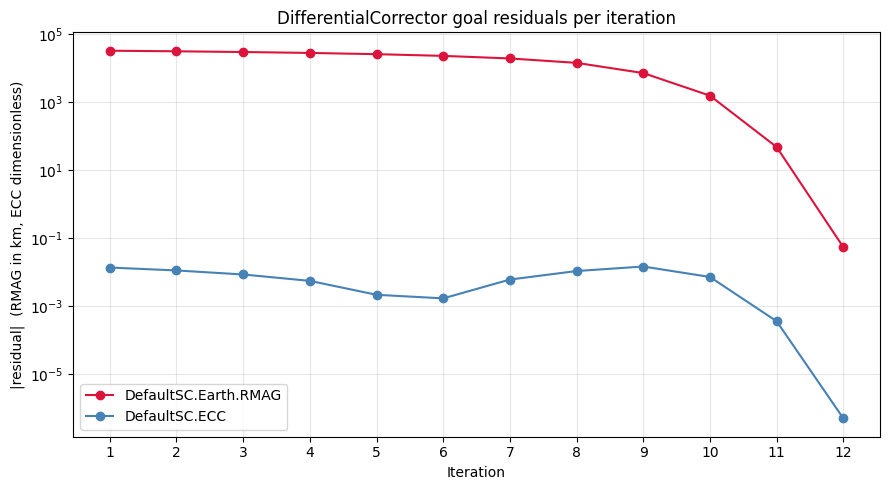

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))

for goal, colour in (("DefaultSC.Earth.RMAG", "crimson"), ("DefaultSC.ECC", "steelblue")):
    ax.plot(
        runs["iteration"],
        runs[f"{goal}_residual"].abs(),
        marker="o",
        linewidth=1.5,
        color=colour,
        label=goal,
    )

ax.set_yscale("log")
ax.set_xlabel("Iteration")
ax.set_ylabel("|residual|  (RMAG in km, ECC dimensionless)")
ax.set_title("DifferentialCorrector goal residuals per iteration")
ax.set_xticks(runs["iteration"])
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

## A run that doesn't converge

A targeter that runs out of iterations is a normal outcome, not an error —
`gmat-run` reports it, it does not raise. To see that, load the same mission
again and cap the `DifferentialCorrector` at a single iteration with a field
override: one iteration is enough for one nominal pass but not enough to take a
correction step.

The re-run completes the same way the first one did. The difference is the
verdict: `converged["DC"]` is now `False`, and the final row's `status` reads
`"max_iter"` — the targeter stopped because it hit `MaximumIterations`, not
because it met its goals. (A targeter that stops for any other reason reports
`"failed"`.)

In [5]:
capped = Mission.load(script_path)
capped["DC.MaximumIterations"] = 1
capped_result = capped.run()

capped_runs = capped_result.solver_runs["DC"]
print(f"Converged:   {capped_result.converged}")
print(f"Last status: {capped_runs['status'].iloc[-1]!r}")

capped_runs

Converged:   {'DC': False}
Last status: 'max_iter'


,iteration,TOI.Element1,GOI.Element1,DefaultSC.Earth.RMAG,DefaultSC.Earth.RMAG_desired,DefaultSC.Earth.RMAG_residual,DefaultSC.Earth.RMAG_tolerance,DefaultSC.ECC,DefaultSC.ECC_desired,DefaultSC.ECC_residual,DefaultSC.ECC_tolerance,status
0,1,0.5,0.5,9746.509926,42165.0,-32418.490074,0.1,0.013654,0.0,0.013654,0.1,max_iter


## What this is not

`solver_runs` is a read-only view over the iteration history GMAT itself wrote.
It does not re-run the optimisation from Python, and it does not expose solver
internals — the Jacobian, its inverse, and the scaled variable estimates a
`DifferentialCorrector` log also records are not parsed into the DataFrame. What
you get is the iteration table: variables, goals, residuals, and the terminal
status.

## Where to next

- **The full schema.** The [`Results`][gmat_run.Results] API reference documents
  every column and `df.attrs` key, including how the column set differs between a
  `DifferentialCorrector` and a `Yukon` optimizer.
- **Optimizers.** `solver_runs` keys an `Optimize` block's `Yukon` run the same
  way it keys this `Target` block's `DC`. A `Yukon` frame swaps the goal quartets
  for a `cost` column and per-constraint residuals.
- **One solver per block.** When several `Target` / `Optimize` blocks share a
  single `Solver` resource, GMAT overwrites its data file per block, so only the
  last block's history survives. Give each block its own `Solver` resource to
  keep every run.